In [1]:
import pandas as pd


In [2]:
from pathlib import Path
import os

import pandas as pd
from dotenv import load_dotenv
from sqlalchemy import create_engine
BASE_DIR = Path.cwd()
BASE_DIR
load_dotenv(BASE_DIR / ".env")
database_url = os.getenv(
    "DATABASE_URL",
    f"sqlite:///{BASE_DIR / 'data' / 'shoppulse.db'}"
)

database_url
engine = create_engine(database_url)

In [5]:
category_gap_df = pd.read_sql(query, engine)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75
2,Kitchen,18,13,12.77,12.15,0.62,72.22
3,Skincare,14,10,9.93,9.35,0.58,71.43
4,Fitness,22,17,15.60,15.89,-0.29,77.27
5,Pet Care,11,9,7.80,8.41,-0.61,81.82
6,Wellness,16,13,11.35,12.15,-0.80,81.25
7,Home Office,20,18,14.18,16.82,-2.64,90.00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

query = """
WITH category_events AS (
    SELECT
        p.category,
        COUNT(CASE WHEN ce.event_type = 'product_view' THEN 1 END) AS product_views,
        COUNT(CASE WHEN ce.event_type = 'add_to_cart' THEN 1 END) AS add_to_cart_events
    FROM products p
    LEFT JOIN click_events ce
        ON p.id = ce.product_id
    GROUP BY p.category
),
totals AS (
    SELECT
        SUM(product_views) AS total_views,
        SUM(add_to_cart_events) AS total_add_to_cart
    FROM category_events
)
SELECT
    ce.category,
    ce.product_views,
    ce.add_to_cart_events,

    ROUND(100.0 * ce.product_views / NULLIF(t.total_views, 0), 2) AS view_share_pct,
    ROUND(100.0 * ce.add_to_cart_events / NULLIF(t.total_add_to_cart, 0), 2) AS add_to_cart_share_pct,

    ROUND(
        100.0 * ce.product_views / NULLIF(t.total_views, 0)
        - 100.0 * ce.add_to_cart_events / NULLIF(t.total_add_to_cart, 0),
        2
    ) AS view_vs_cart_share_gap_pct,

    ROUND(
        100.0 * ce.add_to_cart_events / NULLIF(ce.product_views, 0),
        2
    ) AS view_to_cart_rate_pct
FROM category_events ce
CROSS JOIN totals t
WHERE ce.product_views > 0
ORDER BY view_vs_cart_share_gap_pct DESC;
"""

category_gap_df = pd.read_sql(query, engine)


In [6]:
query_checkout_whatsapp = """
WITH category_carts AS (
    SELECT DISTINCT
        p.category,
        ce.cart_id
    FROM cart_events ce
    JOIN products p
        ON ce.product_id = p.id
    WHERE ce.event_type = 'add_to_cart'
      AND ce.cart_id IS NOT NULL
)

SELECT
    cc.category,
    COUNT(DISTINCT CASE WHEN ce.event_type = 'checkout_started' THEN ce.cart_id END) AS checkout_started_count,
    COUNT(DISTINCT CASE WHEN ce.event_type = 'whatsapp_order_click' THEN ce.cart_id END) AS whatsapp_order_count
FROM category_carts cc
LEFT JOIN cart_events ce
    ON cc.cart_id = ce.cart_id
GROUP BY cc.category;
"""

checkout_whatsapp_df = pd.read_sql(query_checkout_whatsapp, engine)

category_gap_df = category_gap_df.merge(
    checkout_whatsapp_df,
    on="category",
    how="left"
)

category_gap_df[["checkout_started_count", "whatsapp_order_count"]] = (
    category_gap_df[["checkout_started_count", "whatsapp_order_count"]]
    .fillna(0)
    .astype(int)
)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,checkout_started_count,whatsapp_order_count
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67,7,7
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75,5,5
2,Kitchen,18,13,12.77,12.15,0.62,72.22,2,2
3,Skincare,14,10,9.93,9.35,0.58,71.43,2,2
4,Fitness,22,17,15.60,15.89,-0.29,77.27,7,7
5,Pet Care,11,9,7.80,8.41,-0.61,81.82,4,4
6,Wellness,16,13,11.35,12.15,-0.80,81.25,5,5
7,Home Office,20,18,14.18,16.82,-2.64,90.00,7,7


In [7]:
category_gap_df["cart_to_whatsapp_click_ratio_pct"] = (
    100 * category_gap_df["whatsapp_order_count"]
    / category_gap_df["add_to_cart_events"].replace(0, pd.NA)
).round(2)

category_gap_df["cart_to_whatsapp_click_ratio_pct"] = (
    category_gap_df["cart_to_whatsapp_click_ratio_pct"].fillna(0)
)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,checkout_started_count,whatsapp_order_count,cart_to_whatsapp_click_ratio_pct
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67,7,7,43.75
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75,5,5,45.45
2,Kitchen,18,13,12.77,12.15,0.62,72.22,2,2,15.38
3,Skincare,14,10,9.93,9.35,0.58,71.43,2,2,20.00
4,Fitness,22,17,15.60,15.89,-0.29,77.27,7,7,41.18
5,Pet Care,11,9,7.80,8.41,-0.61,81.82,4,4,44.44
6,Wellness,16,13,11.35,12.15,-0.80,81.25,5,5,38.46
7,Home Office,20,18,14.18,16.82,-2.64,90.00,7,7,38.89


In [8]:
query_product_features = """
SELECT
    category,
    COUNT(*) AS total_products,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(AVG(discount_percent), 2) AS avg_discount_pct,
    ROUND(AVG(rating), 2) AS avg_rating,
    SUM(review_count) AS total_reviews,
    ROUND(AVG(stock_quantity), 2) AS avg_stock_quantity,
    COUNT(CASE WHEN is_featured = 1 THEN 1 END) AS featured_product_count
FROM products
WHERE is_active = 1
GROUP BY category;
"""

product_features_df = pd.read_sql(query_product_features, engine)

category_gap_df = category_gap_df.merge(
    product_features_df,
    on="category",
    how="left"
)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,checkout_started_count,whatsapp_order_count,cart_to_whatsapp_click_ratio_pct,total_products,avg_price,avg_discount_pct,avg_rating,total_reviews,avg_stock_quantity,featured_product_count
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67,7,7,43.75,5,759.0,20.0,4.38,1235,222.0,2
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75,5,5,45.45,5,449.0,19.0,4.44,1492,242.0,2
2,Kitchen,18,13,12.77,12.15,0.62,72.22,2,2,15.38,5,979.0,19.0,4.36,1604,196.0,2
3,Skincare,14,10,9.93,9.35,0.58,71.43,2,2,20.00,5,619.0,19.0,4.42,909,214.0,2
4,Fitness,22,17,15.60,15.89,-0.29,77.27,7,7,41.18,5,859.0,22.0,4.40,1015,154.0,2
5,Pet Care,11,9,7.80,8.41,-0.61,81.82,4,4,44.44,5,629.0,21.0,4.38,1545,178.0,2
6,Wellness,16,13,11.35,12.15,-0.80,81.25,5,5,38.46,5,909.0,22.0,4.32,839,164.0,2
7,Home Office,20,18,14.18,16.82,-2.64,90.00,7,7,38.89,5,1159.0,21.0,4.44,696,151.0,2


In [9]:
query_session_features = """
SELECT
    p.category,
    COUNT(DISTINCT ce.session_id) AS unique_sessions,
    COUNT(DISTINCT ce.user_id) AS unique_users
FROM click_events ce
JOIN products p
    ON ce.product_id = p.id
WHERE ce.event_type IN ('product_view', 'add_to_cart')
GROUP BY p.category;
"""

session_features_df = pd.read_sql(query_session_features, engine)

category_gap_df = category_gap_df.merge(
    session_features_df,
    on="category",
    how="left"
)

category_gap_df[["unique_sessions", "unique_users"]] = (
    category_gap_df[["unique_sessions", "unique_users"]]
    .fillna(0)
    .astype(int)
)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,checkout_started_count,whatsapp_order_count,cart_to_whatsapp_click_ratio_pct,total_products,avg_price,avg_discount_pct,avg_rating,total_reviews,avg_stock_quantity,featured_product_count,unique_sessions,unique_users
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67,7,7,43.75,5,759.0,20.0,4.38,1235,222.0,2,20,20
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75,5,5,45.45,5,449.0,19.0,4.44,1492,242.0,2,16,16
2,Kitchen,18,13,12.77,12.15,0.62,72.22,2,2,15.38,5,979.0,19.0,4.36,1604,196.0,2,14,14
3,Skincare,14,10,9.93,9.35,0.58,71.43,2,2,20.00,5,619.0,19.0,4.42,909,214.0,2,13,13
4,Fitness,22,17,15.60,15.89,-0.29,77.27,7,7,41.18,5,859.0,22.0,4.40,1015,154.0,2,17,17
5,Pet Care,11,9,7.80,8.41,-0.61,81.82,4,4,44.44,5,629.0,21.0,4.38,1545,178.0,2,11,11
6,Wellness,16,13,11.35,12.15,-0.80,81.25,5,5,38.46,5,909.0,22.0,4.32,839,164.0,2,15,15
7,Home Office,20,18,14.18,16.82,-2.64,90.00,7,7,38.89,5,1159.0,21.0,4.44,696,151.0,2,16,16


In [10]:
category_gap_df["cart_to_checkout_ratio_pct"] = (
    100 * category_gap_df["checkout_started_count"]
    / category_gap_df["add_to_cart_events"].replace(0, pd.NA)
).round(2)

category_gap_df["checkout_to_whatsapp_ratio_pct"] = (
    100 * category_gap_df["whatsapp_order_count"]
    / category_gap_df["checkout_started_count"].replace(0, pd.NA)
).round(2)

category_gap_df[[
    "cart_to_checkout_ratio_pct",
    "checkout_to_whatsapp_ratio_pct"
]] = category_gap_df[[
    "cart_to_checkout_ratio_pct",
    "checkout_to_whatsapp_ratio_pct"
]].fillna(0)

category_gap_df


,category,product_views,add_to_cart_events,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,checkout_started_count,whatsapp_order_count,cart_to_whatsapp_click_ratio_pct,...,avg_price,avg_discount_pct,avg_rating,total_reviews,avg_stock_quantity,featured_product_count,unique_sessions,unique_users,cart_to_checkout_ratio_pct,checkout_to_whatsapp_ratio_pct
0,Electronics Accessories,24,16,17.02,14.95,2.07,66.67,7,7,43.75,...,759.0,20.0,4.38,1235,222.0,2,20,20,43.75,100.0
1,Healthy Snacks,16,11,11.35,10.28,1.07,68.75,5,5,45.45,...,449.0,19.0,4.44,1492,242.0,2,16,16,45.45,100.0
2,Kitchen,18,13,12.77,12.15,0.62,72.22,2,2,15.38,...,979.0,19.0,4.36,1604,196.0,2,14,14,15.38,100.0
3,Skincare,14,10,9.93,9.35,0.58,71.43,2,2,20.00,...,619.0,19.0,4.42,909,214.0,2,13,13,20.00,100.0
4,Fitness,22,17,15.60,15.89,-0.29,77.27,7,7,41.18,...,859.0,22.0,4.40,1015,154.0,2,17,17,41.18,100.0
5,Pet Care,11,9,7.80,8.41,-0.61,81.82,4,4,44.44,...,629.0,21.0,4.38,1545,178.0,2,11,11,44.44,100.0
6,Wellness,16,13,11.35,12.15,-0.80,81.25,5,5,38.46,...,909.0,22.0,4.32,839,164.0,2,15,15,38.46,100.0
7,Home Office,20,18,14.18,16.82,-2.64,90.00,7,7,38.89,...,1159.0,21.0,4.44,696,151.0,2,16,16,38.89,100.0


In [11]:
category_gap_df = category_gap_df[
    [
        "category",
        "product_views",
        "add_to_cart_events",
        "checkout_started_count",
        "whatsapp_order_count",
        "view_share_pct",
        "add_to_cart_share_pct",
        "view_vs_cart_share_gap_pct",
        "view_to_cart_rate_pct",
        "cart_to_checkout_ratio_pct",
        "checkout_to_whatsapp_ratio_pct",
        "cart_to_whatsapp_click_ratio_pct",
        "unique_sessions",
        "unique_users",
        "total_products",
        "avg_price",
        "avg_discount_pct",
        "avg_rating",
        "total_reviews",
        "avg_stock_quantity",
        "featured_product_count",
    ]
]

category_gap_df


,category,product_views,add_to_cart_events,checkout_started_count,whatsapp_order_count,view_share_pct,add_to_cart_share_pct,view_vs_cart_share_gap_pct,view_to_cart_rate_pct,cart_to_checkout_ratio_pct,...,cart_to_whatsapp_click_ratio_pct,unique_sessions,unique_users,total_products,avg_price,avg_discount_pct,avg_rating,total_reviews,avg_stock_quantity,featured_product_count
0,Electronics Accessories,24,16,7,7,17.02,14.95,2.07,66.67,43.75,...,43.75,20,20,5,759.0,20.0,4.38,1235,222.0,2
1,Healthy Snacks,16,11,5,5,11.35,10.28,1.07,68.75,45.45,...,45.45,16,16,5,449.0,19.0,4.44,1492,242.0,2
2,Kitchen,18,13,2,2,12.77,12.15,0.62,72.22,15.38,...,15.38,14,14,5,979.0,19.0,4.36,1604,196.0,2
3,Skincare,14,10,2,2,9.93,9.35,0.58,71.43,20.00,...,20.00,13,13,5,619.0,19.0,4.42,909,214.0,2
4,Fitness,22,17,7,7,15.60,15.89,-0.29,77.27,41.18,...,41.18,17,17,5,859.0,22.0,4.40,1015,154.0,2
5,Pet Care,11,9,4,4,7.80,8.41,-0.61,81.82,44.44,...,44.44,11,11,5,629.0,21.0,4.38,1545,178.0,2
6,Wellness,16,13,5,5,11.35,12.15,-0.80,81.25,38.46,...,38.46,15,15,5,909.0,22.0,4.32,839,164.0,2
7,Home Office,20,18,7,7,14.18,16.82,-2.64,90.00,38.89,...,38.89,16,16,5,1159.0,21.0,4.44,696,151.0,2


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


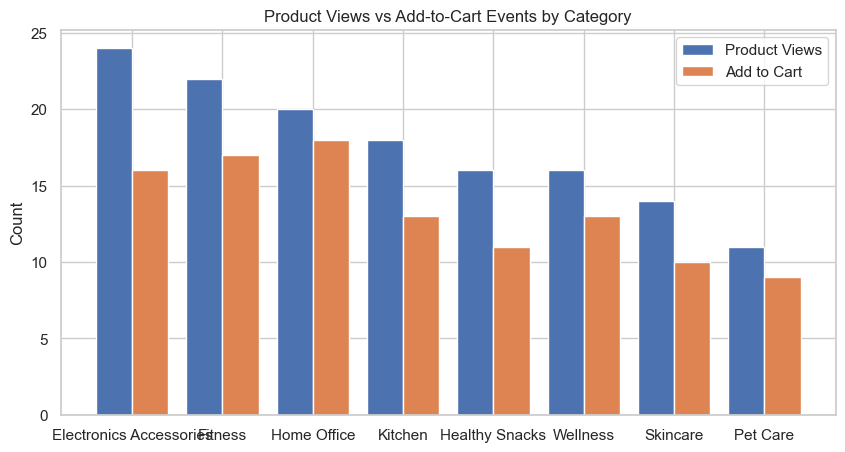

In [13]:
plot_df = category_gap_df.sort_values("product_views", ascending=False)

plt.figure(figsize=(10, 5))

x = range(len(plot_df))

plt.bar(
    x,
    plot_df["product_views"],
    width=0.4,
    label="Product Views"
)

plt.bar(
    [i + 0.4 for i in x],
    plot_df["add_to_cart_events"],
    width=0.4,
    label="Add to Cart"
)

plt.xticks([i + 0.2 for i in x], plot_df["category"])
plt.ylabel("Count")
plt.title("Product Views vs Add-to-Cart Events by Category")
plt.legend()
plt.show()


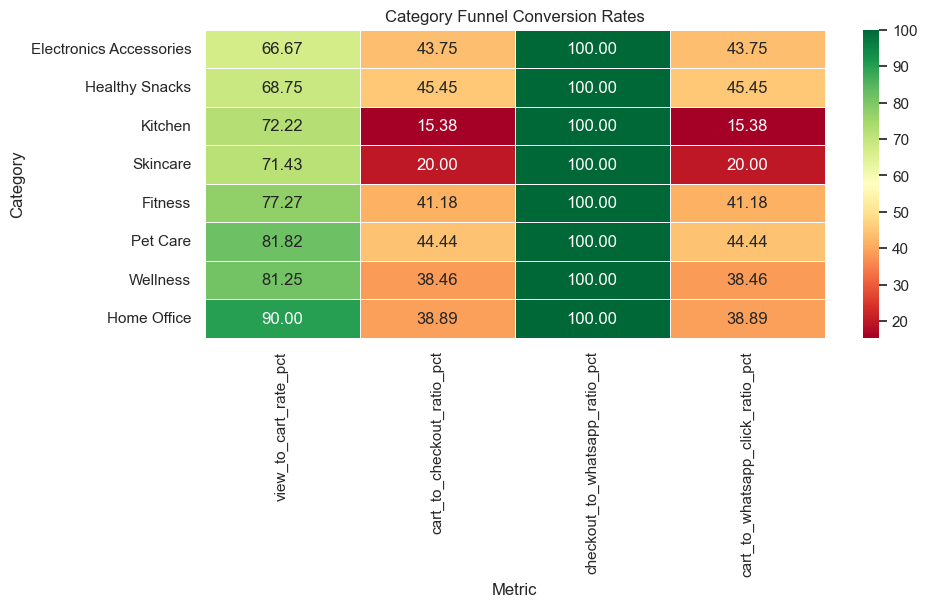

In [14]:
ratio_cols = [
    "view_to_cart_rate_pct",
    "cart_to_checkout_ratio_pct",
    "checkout_to_whatsapp_ratio_pct",
    "cart_to_whatsapp_click_ratio_pct"
]

heatmap_df = category_gap_df.set_index("category")[ratio_cols]

plt.figure(figsize=(10, 4))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5
)

plt.title("Category Funnel Conversion Rates")
plt.ylabel("Category")
plt.xlabel("Metric")
plt.show()
